# ARIM情報活用講座：　ケモインフォマテックス応用編　
# 第2回：　類似度計算と次元削減

## 対象読者・前提知識・動作環境・版とライセンス

**対象読者**：ARIMデータポータル会員の研究者・技術者を想定しています。Pythonの基礎文法は理解しているものとしますが、RDKit・scikit-learn・UMAPなどのライブラリに触れるのは初めてでも読み進められるように構成しています。統計学・機械学習の予備知識は前提としません。

**前提知識**：Python基礎文法、および1_Descriptor.ipynbで扱ったMorganフィンガープリントの基礎（本編はその続編です）。

**動作環境**：Google Colab、または以下のバージョンで動作確認を行いました。

| ライブラリ | バージョン |
| --- | --- |
| Python | 3.10 |
| rdkit | 2026.03.4 |
| scikit-learn | 1.7.2 |
| umap-learn | インストール済みの最新版 |
| pandas / numpy | 2.3.3 / 1.26.4 |

**版とライセンス**：底本は船津 公人、柴山 翔二郎『実践 マテリアルズインフォマティクス　Pythonによる材料設計のための機械学習』（近代科学社、2020）第1章。データセットの出典は本編内で明記します。本ノートブックはARIMデータポータルセミナー・ワークショップ教材として配布します。


## 底本
船津 公人、柴山 翔二郎 **『実践 マテリアルズインフォマティクス　Pythonによる材料設計のための機械学習』**、近代科学社、2020  
第一章　1.3 データの可視化　－次元削減ー

## 本編の目標
RDKitを使って分子記述子の扱い方と、その記述子から分子構造と性能の類似度の相関性をPCAやt-SNE、UMAPで可視化するフローを示します。
* 構造の類似性（Morganフィンガープリントの類似性）は、タニモト係数を使って計算します。
* 次元削減の演習として、構造の類似性のタニモト係数を種々の次元削減のアルゴリズム（PCA, t-SNE,　UMAP）から空間に水溶解度を付置させて相関性を可視化します。

## データセット
delaney-processed.csvは1128化合物の水溶解度についてのデータセットです。このデータセットは、Delaneyの論文『ESOL: Estimating Aqueous Solubility Directly from Molecular Structure』[1] で発表されたものに基づいています。

[1] John S. Delaney, "ESOL:  Estimating Aqueous Solubility Directly from Molecular Structure", J. Chem. Inf. Comput. Sci. 44, 1000–1005 (2004) (DOI: 10.1021/ci034243x)  

Delaney-processed.csvは、分子の化学式、SMILES表記、および水溶解度（log S、mol/L単位の対数値）の実測値・予測値が含まれており、これらの特性は薬物探索や環境影響評価などの目的で使用されています。

《注意》水溶解度（log S）とオクタノール水分配係数（log P）は異なる物性値です。このデータセットにはlog P列は含まれていません。


1. Compound ID	：化合物ID
1. ESOL predicted log solubility in mols per litre　：log水溶解度の予測値（ESOLモデルによる推定値）	
1. Minimum Degree：　最小次数	
1. Molecular Weight：分子量	
1. Number of H-Bond Donors	：　水素結合に関与するDonor数
1. Number of Rings	：芳香環の数	
1. Number of Rotatable Bonds　：　回転可能結合数	
1. Polar Surface Area　：　極性表面積	
1. measured log solubility in mols per litre：log水溶解度の実測値	
1. smiles：SMILES表記

# Google Colabにおける環境設定
google colab環境でなければ実行不要

In [ ]:
!pip install rdkit
!pip install umap-learn
! pip install matplotlib_fontja
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_3_Chemoinformatics.git
%cd Advanced_Tutorial_3_Chemoinformatics

## 1.分子構造データの読み込み　（P.11）

### 汎用ライブラリのインポート

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

from warnings import filterwarnings
filterwarnings('ignore')# 警告を無視

### サンプルファイルの読み込み
ここでは「data/dataset」フォルダーにあるdelaney-processed.csvをpandasの`read_csv()`からデータフレーム（DataFrame）オブジェクトとして変数dfに格納します。dfは1128化合物に対して10の特徴量からなるデータ行列となっていることが確かめられます。

In [2]:
df = pd.read_csv('./data/dataset/delaney-processed.csv')
df['mol']=df['smiles'].apply(Chem.MolFromSmiles)
df

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,mol
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.770,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,<rdkit.Chem.rdchem.Mol object at 0x76b2fd018820>
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.300,Cc1occc1C(=O)Nc2ccccc2,<rdkit.Chem.rdchem.Mol object at 0x76b2fd018890>
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.060,CC(C)=CCCC(C)=CC(=O),<rdkit.Chem.rdchem.Mol object at 0x76b2fd018900>
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.870,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,<rdkit.Chem.rdchem.Mol object at 0x76b2fd018970>
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.330,c1ccsc1,<rdkit.Chem.rdchem.Mol object at 0x76b2fd0189e0>
...,...,...,...,...,...,...,...,...,...,...,...
1123,halothane,-2.608,1,197.381,0,0,0,0.00,-1.710,FC(F)(F)C(Cl)Br,<rdkit.Chem.rdchem.Mol object at 0x76b2fd05f760>
1124,Oxamyl,-0.908,1,219.266,1,0,1,71.00,0.106,CNC(=O)ON=C(SC)C(=O)N(C)C,<rdkit.Chem.rdchem.Mol object at 0x76b2fd05f7d0>
1125,Thiometon,-3.323,1,246.359,0,0,7,18.46,-3.091,CCSCCSP(=S)(OC)OC,<rdkit.Chem.rdchem.Mol object at 0x76b2fd05f840>
1126,2-Methylbutane,-2.245,1,72.151,0,0,1,0.00,-3.180,CCC(C)C,<rdkit.Chem.rdchem.Mol object at 0x76b2fd05f8b0>


## 2.分子の類似度計算 （タニモト係数）　（底本P12）
### 作業の流れ
分子構造どうしの類似性を定量的に比較するための指標である**タニモト係数**（およびその補数である**タニモト距離**）の算出手順を学びます。本編では、同じタニモト係数を次の2つの目的で使います。

1. Morganフィンガープリントを0/1の256ビットとして取り出す
1. 全1128化合物どうしのタニモト**距離**を総当たりで計算し、距離行列を作る（次元削減（PCA・t-SNE・UMAP）の入力として使用）
1. 特定の参照化合物1つを基準に、他の全化合物とのタニモト**係数（類似度）**を計算し、類似化合物を検索する

「係数（coefficient）」は値が1に近いほど類似、「距離（distance）」は値が0に近いほど類似、と向きが逆になる点に注意してください（距離 = 1 − 係数）。


### タニモト係数とは

タニモト係数は、化学構造の類似性を評価するための指標として広く使用される重要な指標です。2つの化合物のバイナリフィンガープリントを比較し、共通してオンになっているビットの数を、少なくとも一方でオンになっているビットの数（和集合のサイズ）で割って計算されます。タニモト係数は、0から1の範囲の値を取り、値が1に近いほど化合物の類似性が高いことを示します。

具体的には、2つの集合`A`と`B`のタニモト係数は次のように計算されます：

```
Tanimoto (Jaccard) coefficient = |A ∩ B| / (|A| + |B| - |A ∩ B|) = |A ∩ B| / |A ∪ B|
```

ここで、|A| は集合Aの要素数、|B| は集合Bの要素数、|A ∩ B| は2つの集合の共通要素数、|A ∪ B|（= |A| + |B| − |A ∩ B|）は和集合の要素数を表します。

これと対になる指標が**タニモト距離（Tanimoto distance）**で、次のように定義されます：

```
Tanimoto (Jaccard) distance = 1 - Tanimoto coefficient = 1 - |A ∩ B| / |A ∪ B|
```

タニモト距離は0から1の範囲の値を取り、値が0に近いほど2つの集合は類似していることを示します（係数は値が大きいほど類似、距離は値が小さいほど類似と、向きが逆になる点に注意してください）。

分子フィンガープリントのようなバイナリ（0/1）ベクトルの場合、この「タニモト係数」は**ジャカード係数（Jaccard index）**と数学的に完全に等価です。したがって「1 − タニモト係数」であるタニモト距離は、`scipy`など汎用ライブラリの**ジャカード距離（Jaccard distance）**と完全に一致します。呼び名が違うだけで、同じ計算をしていると理解してください。

《注意》Tanimoto (1957)が最初に提案した係数は、一般の（0/1に限らない）ベクトル `a`, `b` に対して `T(a,b) = a·b / (|a|² + |b|² − a·b)` という内積ベースの式で定義されています。ベクトルの各要素が0または1（部分構造の有無）の場合、この式は上記の集合ベースの式と数値的に一致します。本編では以降、RDKitの`DataStructs`モジュールが提供する`TanimotoSimilarity`系のメソッドを使ってこれを計算します。


### Morganフィンガープリント

delaney溶解度に含まれる1128化合物について、半径3でビットベクトル256のMorganフィンガープリントをリスト内包表記（list comprehension）で一括計算し出力します。

In [3]:
from rdkit.Chem import rdFingerprintGenerator as fg

# Morgan fingerprint定義
fp = fg.GetMorganGenerator(radius=3, fpSize=256)

# Morgan fingerprintsの出力
X = np.matrix([fp.GetFingerprintAsNumPy(m) for m in df['mol']])
X

matrix([[1, 1, 1, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 1]], dtype=uint8)

In [4]:
#非推奨のAllChem.GetMorganFingerprintAsBitVectでの出力方法

#X = np.matrix([AllChem.GetMorganFingerprintAsBitVect(m, radius=3, nBits=256) for m in df['mol']])
#X

《注意：フィンガープリントの実装とビット数について》

**非推奨メソッドについて**：RDKitの以前のバージョンでは、上のセルでコメントアウトしている`AllChem.GetMorganFingerprintAsBitVect`が広く使われていましたが、現在のバージョンでは`rdFingerprintGenerator`（`GetMorganGenerator`）の使用が推奨されています（`GetMorganFingerprintAsBitVect`を呼ぶとDEPRECATION WARNINGが表示されます）。Web上の古い記事やコードでは`GetMorganFingerprintAsBitVect`がまだ多く見られるため、両者が同じ計算を行っていることを知っておくと混乱を防げます（1_Descriptor.ipynbで両者が完全に同じ値を返すことを実際に検証しています）。

**ビット数（`fpSize`）とビット衝突について**：本編では可視化のしやすさを優先して`fpSize=256`という小さめの値を使っていますが、半径3（ECFP6相当）のように広い部分構造まで探索する設定でビット数を絞ると、異なる部分構造が同じビットに割り当てられてしまう「ビット衝突（collision）」がかなりの頻度で起こります。次のセルで、実際にこのデータセットで何個の部分構造が衝突しているかを数えてみましょう。


In [5]:
# 半径3で生成される「ハッシュ化前のユニークな部分構造」の総数を数える
# （GetSparseCountFingerprintはビット長を制限しないため、衝突が起こらない）
fp_sparse = fg.GetMorganGenerator(radius=3)
unique_substructures = set()
for m in df['mol']:
    unique_substructures.update(fp_sparse.GetSparseCountFingerprint(m).GetNonzeroElements().keys())

n_unique = len(unique_substructures)
print(f"データセット全体でのユニークな部分構造の数: {n_unique}")
print(f"256ビットに割り当てた場合の1ビットあたり平均衝突数: {n_unique/256:.1f}")
print(f"2048ビットに割り当てた場合の1ビットあたり平均衝突数: {n_unique/2048:.1f}")

データセット全体でのユニークな部分構造の数: 9144
256ビットに割り当てた場合の1ビットあたり平均衝突数: 35.7
2048ビットに割り当てた場合の1ビットあたり平均衝突数: 4.5


実際に計算すると、Delaneyデータセット1128化合物全体で半径3の部分構造は数千種類存在しており、これを256ビットに収めると1ビットあたり平均で数十個の異なる部分構造が衝突していることになります（2048ビットであれば1桁台まで減ります）。**実際の研究や予測モデルの構築では、ビット衝突を避けるために1024や2048ビットを指定することが一般的です**。本編で256ビットを使うのは、あくまで可視化や計算を軽くするための教材上の簡略化である点に注意してください。


In [6]:
X.shape

(1128, 256)

### タニモト距離の計算
1128化合物の総当たりのタニモト距離の計算はscipyに含まれているpdist関数を使って行えます。

In [7]:
from scipy.spatial.distance import pdist, squareform

distances = pdist(X, metric='jaccard')

# 距離ベクトルを元の行列形式に変換
D = squareform(distances)
D.shape

(1128, 1128)

このようにすることで、`distance_matrix`は元のデータセットのデータポイント間の距離行列を表します。

In [8]:
D

array([[0.        , 0.8125    , 0.86486486, ..., 0.91139241, 0.95384615,
        0.8988764 ],
       [0.8125    , 0.        , 0.84313725, ..., 0.92982456, 0.97619048,
        0.80327869],
       [0.86486486, 0.84313725, 0.        , ..., 0.91304348, 0.89655172,
        0.89285714],
       ...,
       [0.91139241, 0.92982456, 0.91304348, ..., 0.        , 0.86666667,
        0.87719298],
       [0.95384615, 0.97619048, 0.89655172, ..., 0.86666667, 0.        ,
        0.97777778],
       [0.8988764 , 0.80327869, 0.89285714, ..., 0.87719298, 0.97777778,
        0.        ]])

【解説】scipyを用いた様々な距離の計算方法
* `scipy.spatial.distance`モジュールから`pdist`と`squareform`をインポートすることで、データセット内のデータポイント間の距離を計算する機能を利用することができます。

* `pdist`関数は、与えられたデータセット内のデータポイント間の距離を計算します。データセットは通常、2次元または多次元の配列として表され、各行が個々のデータポイントを表します。距離計算には、さまざまな距離尺度（ユークリッド距離、マンハッタン距離、コサイン距離、ジャカード距離など）を使用することができます。`pdist`関数は、計算された距離を圧縮したベクトル形式で返します。

* `squareform`関数は、`pdist`関数によって得られた距離ベクトルを元の行列形式に変換します。具体的には、距離ベクトルを対称行列に変換します。この行列は、元のデータセット内の各データポイントの間の距離を表現します。対称行列の要素は、元のデータセットの対応するデータポイント間の距離に対応しています。


* 以下は、`pdist`と`squareform`を使用してデータセット内のデータポイント間の距離行列を計算し、それを元の行列形式に変換する一般的な使用例です。

```python
from scipy.spatial.distance import pdist, squareform

# データセットの準備
data = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]

# データポイント間の距離行列を計算
distances = pdist(data, metric='euclidean')

# 距離ベクトルを元の行列形式に変換
distance_matrix = squareform(distances)
```

《注意》`metric='jaccard'`は、入力を0/1のバイナリ配列として扱い、ジャカード距離（= 1 − ジャカード係数）を計算します。分子フィンガープリントのような0/1ベクトルでは、ジャカード係数とタニモト係数は数値的に一致するため、`pdist(X, metric='jaccard')`は「1 − タニモト係数」、すなわち**タニモト距離**を計算していることになります（実際に`rdkit.DataStructs.BulkTanimotoSimilarity`で計算した値と一致することを確認できます）。


### タニモト距離の可視化

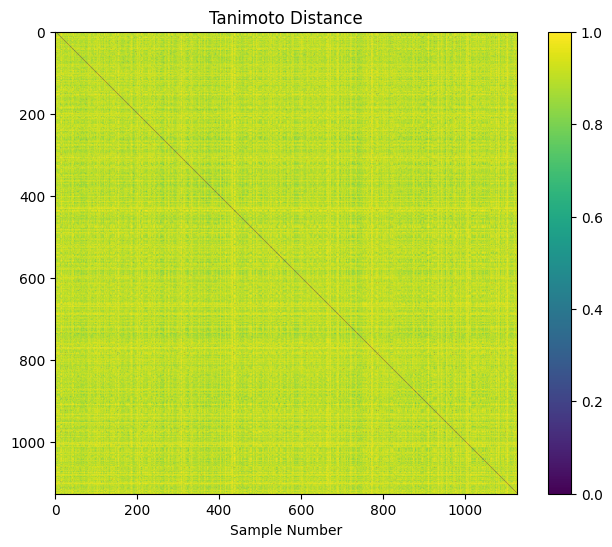

In [9]:
# 図1：全1128化合物間のタニモト距離行列（底本 図1.4相当）

fig = plt.subplots(figsize=(8, 6))
plt.imshow(D)
plt.colorbar()

plt.title('Tanimoto Distance')
plt.xlabel('Sample Number')

#plt.savefig('./results/eda/tanimotocoef.png')

plt.show()

1128化合物のうち、化合物IDが0番～40番までの範囲で相関図を見てみることにしましょう。

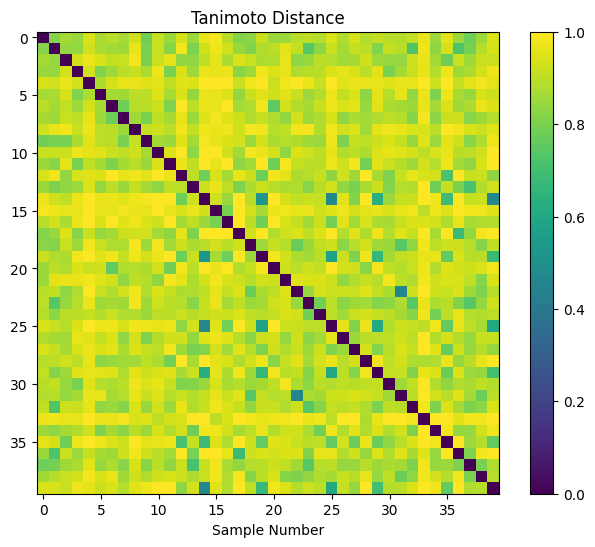

In [10]:
# 図2：化合物ID 0〜39番のタニモト距離行列（拡大表示）
fig = plt.subplots(figsize=(8, 6))

subset = D[0:40, 0:40]

plt.imshow(subset)
plt.colorbar()

plt.title('Tanimoto Distance')
plt.xlabel('Sample Number')

#plt.savefig('./results/eda/tanimotocoef.png')

plt.show()

### 化合物の類似性検索

参照分子との類似性を計算します。以下は、Morganフィンガープリントを使用してRDKitの`DataStructs`モジュールにある`TanimotoSimilarity`系のメソッドから**タニモト係数（類似度）**を計算する例です（前節の距離行列とは異なり、ここで計算するのは値が1に近いほど類似という「係数」であることに注意してください）。

ここでは、下記の化合物をDelaneyの1128の化合物の中からタニモト係数で最も類似性のある化合物を検索します。Morganフィンガープリントとして半径2としてセットします。


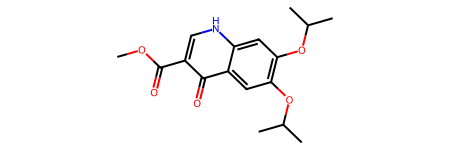

In [11]:
ref_smiles = 'COC(=O)c1c[nH]c2cc(OC(C)C)c(OC(C)C)cc2c1=O'
ref_mol = Chem.MolFromSmiles(ref_smiles)
ref_mol

In [12]:
# Create Morgan fingerprint generator with radius=2
fp = fg.GetMorganGenerator(radius=2, fpSize=2048)

# Generate Morgan fingerprint for reference molecule
ref_fps = fp.GetFingerprint(ref_mol)

上記以外の1127化合物のフィンガープリントをリスト内包表記を使って計算します。

In [13]:
bulk_fps = [fp.GetFingerprint(x) for x in df['mol']]

【解説】 **`TanimotoSimilarity()`** と **`BulkTanimotoSimilarity()`**

RDKitの`DataStructs`モジュールには、2つのフィンガープリント間の類似度を計算する方法がいくつか用意されています。

- `DataStructs.FingerprintSimilarity(fp1, fp2, metric=...)`：類似度指標を`metric`引数で切り替えられる汎用メソッド。`metric`を省略するとデフォルトでタニモト係数が使われます
- `DataStructs.TanimotoSimilarity(fp1, fp2)`：2つのフィンガープリント間のタニモト係数を直接計算する専用メソッド。内部的には`FingerprintSimilarity`のデフォルト動作と同じ値を返しますが、「タニモト係数を計算している」ことがメソッド名から明確です
- `DataStructs.BulkTanimotoSimilarity(fp, fps)`：1つの参照フィンガープリント`fp`と、複数のフィンガープリントのリスト`fps`とのタニモト係数を、まとめて（一括で）計算するメソッド

```python
from rdkit import DataStructs

# 1組のペアだけを計算する場合
sim = DataStructs.TanimotoSimilarity(fp1, fp2)

# 1つの参照と多数の分子との類似度をまとめて計算する場合
sims = DataStructs.BulkTanimotoSimilarity(fp_ref, fps_list)
```

`BulkTanimotoSimilarity`は、Pythonの`for`文で`TanimotoSimilarity`を1件ずつ呼び出すのと同じ結果を返しますが、内部でC++実装のループを使うため、化合物数が多い場合はPythonの`for`文（あるいはリスト内包表記）で回すより高速です。次のセルでは、まず1組のペアで`TanimotoSimilarity`の使い方を確認し、続けて1128化合物全体との比較には`BulkTanimotoSimilarity`を使います。


1128化合物それぞれとのタニモト係数（類似度）を`BulkTanimotoSimilarity`でまとめて計算し、'Tanimoto_Similarity'のカラム名でデータフレームに追加します。あわせて、1組だけを`TanimotoSimilarity`で個別に計算した場合と値が一致することも確認します。


In [14]:
from rdkit import DataStructs

# 1組の分子ペアについて、TanimotoSimilarity()で直接タニモト係数を計算する例
example_similarity = DataStructs.TanimotoSimilarity(ref_fps, bulk_fps[0])
print(f"参照化合物と0番目の化合物とのタニモト係数: {example_similarity:.4f}")

# 1128化合物全体との類似度は、BulkTanimotoSimilarity()でまとめて計算する
similarity = DataStructs.BulkTanimotoSimilarity(ref_fps, bulk_fps)
df['Tanimoto_Similarity'] = similarity

# 上のexample_similarityと、一括計算した0番目の結果が一致することを確認
assert example_similarity == similarity[0]


参照化合物と0番目の化合物とのタニモト係数: 0.0800


In [15]:
df['Tanimoto_Similarity']

0       0.080000
1       0.157895
2       0.054545
3       0.062500
4       0.022727
          ...   
1123    0.021277
1124    0.101695
1125    0.072727
1126    0.071429
1127    0.155172
Name: Tanimoto_Similarity, Length: 1128, dtype: float64

上位8件の化合物について、参照化合物とのタニモト係数（類似度）を`PandasTools`で見てみましょう。

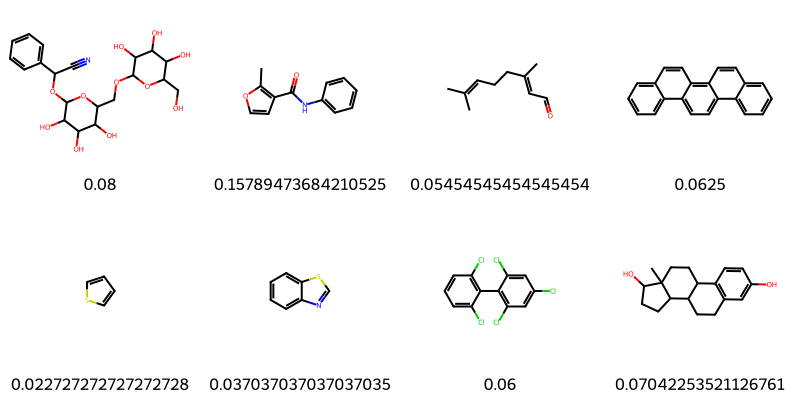

In [16]:
from rdkit.Chem import PandasTools
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')
PandasTools.FrameToGridImage(df.head(8), legendsCol="Tanimoto_Similarity", molsPerRow=4)

類似度を**降順**に並べ替えると、参照化合物に最も類似した化合物から順に表示されます。


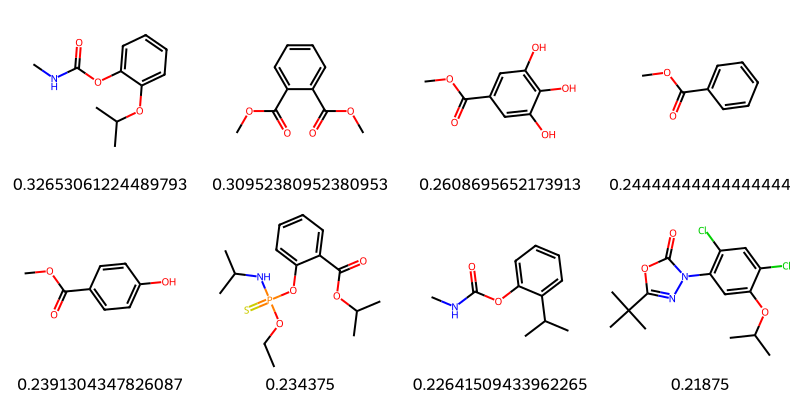

In [17]:
esol_data = df.sort_values(['Tanimoto_Similarity'], ascending=False)
PandasTools.FrameToGridImage(esol_data.head(8), legendsCol="Tanimoto_Similarity", molsPerRow=4)

【留意事項】  
タニモト係数を用いた化合物の類似度検索において、フィンガープリントの選択は重要な要素となりますが、下記の留意すべき点があります。

1. フィンガープリントのタイプ：タニモト係数を計算するためには、比較する化合物のフィンガープリントが同じタイプ（同じ生成方法・同じパラメータ）である必要があります。異なるタイプのフィンガープリントを比較することはできません。

2. フィンガープリントのパラメータ：フィンガープリントの計算において、半径（`radius`）やビット数（`fpSize`）などのパラメータを変更すると、フィンガープリントの特徴が変わり、類似度の計算結果にも影響を及ぼす可能性があります。

3. フィンガープリントのビット長：ビット長は、類似度検索の結果に大きな影響を与えます。ビット長が長い場合、より詳細な情報を持つフィンガープリントになりますが、計算コストも増加します。ビット長が短すぎると、異なる部分構造が同じビットに重なる「衝突（collision）」が起こりやすくなります。

4. 化合物データの特性：使用するフィンガープリントの選択は、化合物データの特性に応じて検討する必要があります。例えば、特定のタイプの化合物ライブラリに対して最適なフィンガープリントが異なる場合があります。

5. 類似度指標の選択：タニモト係数はフィンガープリントの類似度を計算する指標の一つですが、他にも類似度指標があります（例：Dice係数、コサイン類似度、Tversky係数など）。指標によって値の大きさの傾向が異なるため、比較する際はどの指標を使ったかを明記する必要があります。

これらの留意点を考慮して、タニモト係数を用いた化合物の類似度検索を適切に行うためには、適切なフィンガープリントの選択とパラメータの調整が重要です。データセットや特定の化合物データに合わせて最適なフィンガープリントを選ぶことで、より有用な類似度検索結果を得ることができます。


《注意：距離行列の扱いについて》

以下のPCA・t-SNE・UMAPはいずれも、タニモト距離行列`D`（1128×1128）を**そのまま数値の特徴量行列として**入力しています。これは「化合物iについて、他の1127化合物それぞれとのタニモト距離を並べた1127次元のベクトル」を化合物iの特徴量とみなす簡便な方法で、本編でもこの方法を採用します。

一方で、`D`は本来「距離そのもの」を表す行列であるため、t-SNEやUMAPには`metric='precomputed'`という引数を指定して「これは既に計算済みの距離行列である」と明示的に伝える使い方もあります。両者は数学的に等価ではありません。本編末の演習問題で、両者の埋め込み結果がどの程度似ているかを実際に比較します。

さらに厳密に言うと、PCA（主成分分析）は本来、ユークリッド空間上の生の特徴量行列（例えば本編前半で作った0/1のフィンガープリント行列`X`）を受け取り、データの分散が最大になる方向を探す手法です。距離行列`D`をそのまま`sklearn.decomposition.PCA`に入力するのは、教科書的には最も厳密なやり方ではありません。距離行列を理論的に正しく扱いたい場合は、距離行列を二重中心化してから固有値分解を行う**古典的多次元尺度構成法（Classical MDS、`sklearn.manifold.MDS`）**や、`sklearn.decomposition.KernelPCA`（`kernel='precomputed'`）、`TruncatedSVD`などを使うのが理論的に妥当なアプローチです。一方でt-SNE・UMAPは`metric='precomputed'`という引数を明示的に用意しており、距離行列を直接受け取れるよう設計されています。

本編では、底本の方針に従い、PCA・t-SNE・UMAPのいずれにも`D`をそのまま入力するという簡略化した方法を採用しています。次元削減の考え方を体験する教材としてはこれで十分ですが、**研究や実務でPCAに距離行列を使いたい場合は、上記のKernel PCAやMDSなど、距離行列の入力を前提とした手法を検討してください**。


## 3.次元削減　（底本P12）
次元削減の意義と機械学習における活用方法や手法についてまとめます。

1. 次元削減の意義:
   - 高次元のデータにおいて、次元が増えるとデータの可視化や理解が困難になるため、次元削減は重要です。
   - 高次元のデータでは、冗長な情報やノイズが存在することが多く、次元削減によってこれらを取り除くことでデータの質を向上させることができます。
   - 次元削減によってデータの特徴を抽出し、計算の効率化や過学習の軽減など、機械学習モデルの性能向上に寄与することができます。  


2. 機械学習における次元削減の活用方法:
   - 特徴選択（Feature Selection）: 高次元の特徴空間から重要な特徴を選択し、それに基づいてモデルを構築することで、計算効率の向上やモデルの性能向上を図ります。
   - 特徴抽出（Feature Extraction）: 高次元のデータを低次元の新たな特徴空間に射影することで、データの表現を簡素化し、計算効率やモデルの性能向上を図ります。
   - データ可視化: 次元削減はデータの可視化にも利用されます。データを低次元に射影することで、データのクラスタリングや分布の構造を可視化し、洞察を得ることができます。


以下は、代表的な次元削減の手法である主成分分析（PCA）、t-SNE、UMAPの定義と活用方法を表形式でまとめたものです。

| 手法 | 　　線形性　　　 | 定義|
| :---: | :---: |:---: |
| 主成分分析（PCA） |　　線形　　| 元の多次元空間データの情報をできるだけ保持しつつ、<br>データの変動を最大限に捉える主成分空間への射影する手法  |
| t-SNE（t-Distributed Stochastic Neighbor Embedding）|　　 非線形　　　 | 高次元データを低次元空間に埋め込むことで、データ間の類似性や<br>クラスタ構造をできるだけ保持しつつ、可視化を行う手法。|
| UMAP（Uniform Manifold Approximation and Projection）|　　非線形　　　 | 高次元データを低次元のマニフォールド（滑らかな多様体）上に<br>確率的な近似に基づいて埋め込みの最適化を行う手法。|

### 3.1 PCAによる次元削減
scikit-learnライブラリから標準化（StandardScaler）、主成分分析（PCA）、パイプライン（Pipeline）をインポートします。 

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

《注意》ここで`PCA`に入力しているのは、直前に計算したタニモト**距離行列`D`**（1128×1128）です。フィンガープリントの0/1行列`X`そのものではありません。この使い方の妥当性については、前節の《注意：距離行列の扱いについて》を参照してください。

#### 主成分分析(PCA)の計算
主成分分析（PCA）においては、異なる尺度や単位を持つ変数間のスケールの違いを取り除くために標準化（または正規化）を行います。  

* StandardScalerは、データを平均0、標準偏差1に変換するための標準化を行うためのクラスです。主成分分析（PCA）を適用する前にデータを標準化する際に使用されます。  

* make_pipelineは、複数の変換器や推定器を組み合わせてパイプラインを構築するためのメソッドで、データの前処理とモデルの学習・予測を一連のステップとして連結させることができます。

ここでは、主成分分析の前にデータの標準化が必要であるため、パイプラインを構築する際にStandardScalerとPCAを組み合わせることを行います。

In [19]:
pca = make_pipeline(StandardScaler(), PCA())
T_pca = pca.fit_transform(D)

#### 主成分分析(PCA)の寄与率の算出
各主成分が全体の情報をどれくらい説明ができているかを示す「寄与率」をexplained_variance_ratio_から取得します。

In [20]:
ratio_ = dict(pca.steps)['pca'].explained_variance_ratio_
ratio_

array([2.75234016e-01, 1.27286284e-01, 6.93471605e-02, ...,
       3.05132292e-36, 2.88580205e-36, 2.83664015e-36])

#### 主成分分析(PCA)の可視化
主成分分析（PCA）の結果を可視化するための散布図を作成します。ここでは、主成分分析の結果である主成分スコア（T_pca）の第一主成分と第二主成分の2つの主成分を取り出し、またその値の色はy = 'measured log solubility in mols per litre'に基づいて変えています。

この散布図は、「構造的に似ている（タニモト距離が近い）化合物どうしは、低次元空間でも近くにプロットされる」という前提のもとで作られています。**色（測定溶解度）の分布に注目してください**：もし近くにプロットされた点（構造が似ている化合物）が似た色（似た溶解度）を持つ傾向があれば、「構造の類似性が物性（溶解度）の類似性とある程度対応している」と読み取れます。逆に、近くの点で色がバラバラであれば、構造は似ていても溶解度は似ていない、ということになります（これは構造活性相関＝SARの「局所性」を確認する視点です）。t-SNE・UMAPの散布図でも同じ観点で見てみましょう。


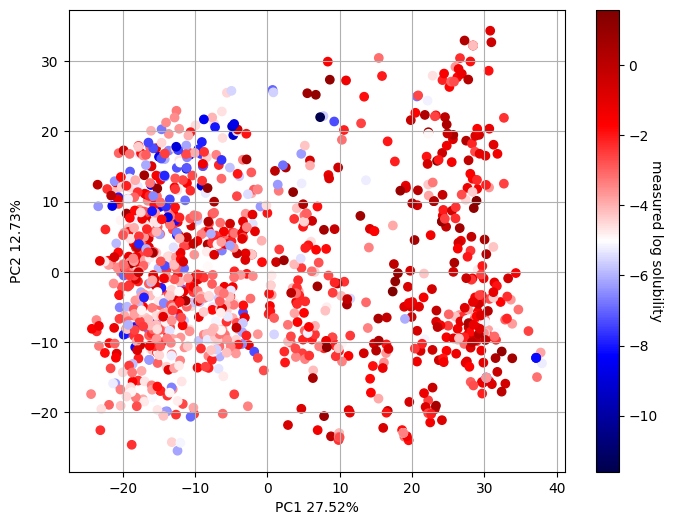

In [21]:
# 図3：タニモト距離行列に対するPCA（測定溶解度で色分け）
fig = plt.subplots(figsize=(8, 6))

y = df['measured log solubility in mols per litre'].values
plt.scatter(T_pca[:,0],T_pca[:,1], c=y, cmap=plt.cm.seismic)

plt.xlabel('PC1 {:.2f}%'.format(ratio_[0]*100))
plt.ylabel('PC2 {:.2f}%'.format(ratio_[1]*100))

cbar = plt.colorbar()
cbar.set_label('measured log solubility', rotation = 270)

plt.grid()
plt.show()

#### 考察例

1. Tanimoto係数で似ているとされている構造でも、log水溶解度は必ずしも近くならない
1. また、クラスターは特に出来ていないため、データを分ける必要はなさそう

### 3.2 t-SNEによる次元削減

t-SNE（t分布型確率的近傍埋め込み法：t-Distributed Stochastic Neighbor Embedding）は、非線形な次元削減手法の一つです。


**特徴**  
t-SNEは、高次元データの視覚化や特徴の圧縮に使用されます。特に、近くにあるデータポイントどうしの**局所的な類似性**を低次元空間でも維持することを重視した手法です。

t-SNEは、主に2つのステップから構成されます。まず、高次元データの類似度（近傍関係）を確率分布として表現します。次に、その確率分布をできるだけ再現するように、低次元空間上の点の位置を最適化します。

**アルゴリズム**  
t-SNEは、データポイントの位置を定めるために確率的なアプローチを使用しており、データポイント間の類似度に基づいて確率分布を作成します。高次元データでは、近くにあるデータポイントの類似度が高いことが多いため、近くのデータポイント間の確率は高くなります。同様に、低次元空間でも近くにあるデータポイント間の確率が高いように調整されます。この確率分布の最適化には、確率的勾配降下法が使用されます。

**利点**  
t-SNEの利点は、特にデータの局所的な構造やクラスタリングの特徴を視覚的に表現できる点です。近傍関係が保たれるため、似た分子どうしが低次元空間でも近くに配置されやすくなります。

**制約・注意点**  
t-SNEにはいくつかの制約もあります。

- 計算コストが高いため、大規模なデータセットでは時間がかかる場合があります
- 異なる実行ごとに結果が異なることがあるため、再現性に注意する必要があります（本編では`random_state`を固定しています）
- **局所的な近傍関係の保存を優先する設計のため、クラスター間の距離やクラスターの大きさといった大域的（グローバル）な構造は必ずしも正しく反映されません**。「2つのクラスターが離れて描かれている＝元の空間でも大きく異なる」とは限らず、逆に元は近かった点が離れて描かれることもあります。本編末の①の比較（元のタニモト距離との相関係数）でも、この点を定量的に確認します


#### ライブラリ  
scikit-learnライブラリからt-SNE（t-distributed Stochastic Neighbor Embedding）をインポートします。

In [22]:
from sklearn.manifold import TSNE

#### t-SNEの計算  
TSNEクラスのインスタンスを作成します。n_componentsパラメータは、埋め込まれる空間の次元数を指定します。ここでは2次元に埋め込むためにn_componentsを2に設定しています。

In [23]:
tsne = TSNE(n_components=2, random_state=66)
T_tsne = tsne.fit_transform(D)

#### t-SNEの可視化
（PCAと同様に、色＝測定溶解度の分布から、構造の類似性と物性の類似性が対応しているかを見てみましょう。）


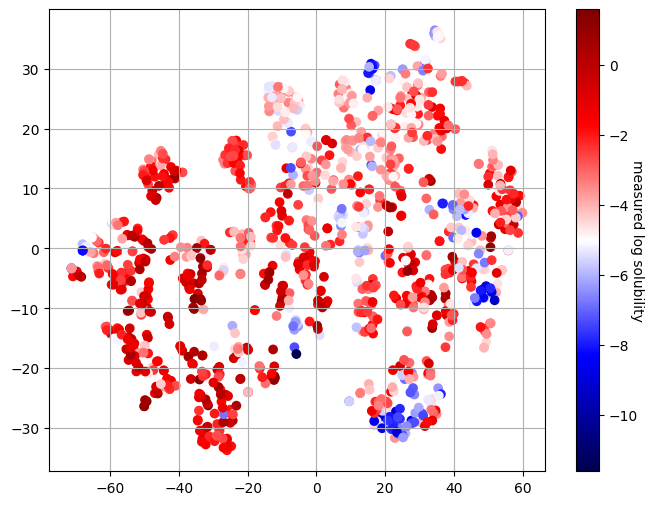

In [24]:
# 図4：タニモト距離行列に対するt-SNE（測定溶解度で色分け）
fig = plt.subplots(figsize=(8, 6))

y = df['measured log solubility in mols per litre'].values
plt.scatter(T_tsne[:,0],T_tsne[:,1], c=y, cmap=plt.cm.seismic)

cbar = plt.colorbar()
cbar.set_label('measured log solubility', rotation = 270)

plt.grid()
plt.show()

### 3.3 UMAPによる次元削減

Uniform Manifold Approximation and Projection (UMAP) は、高次元データを低次元に次元削減し、データの構造やパターンを視覚化するためのデータ分析技術です。以下の３つの仮定に基づいています。

* データはリーマン多様体上で均等に分布している。
* リーマン計量は局所的に一定である。
* 多様体は局所的に連結している。

これらの仮定から、多様体を位相的な構造でモデル化することが可能です。埋め込みは、最も近いぼんやりとした位相的な構造を持つデータの低次元射影を探索することによって見つけます。基礎となる数学の詳細については、以下のArXivの論文に記載されています。

McInnes, L, Healy, J, Melville, J, UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction, ArXiv e-prints 1802.03426, 2018（https://arxiv.org/abs/1802.03426）  

また、pythonにおけるライブラリは、以下から参照できます。  
https://umap-learn.readthedocs.io/en/latest/  

#### ライブラリ
umap-learn（Uniform Manifold Approximation and Projection）ライブラリからUMAP（Uniform Manifold Approximation and Projection）をインポートします。

In [25]:
from umap import UMAP

#### UMAPの計算  
UMAPクラスのインスタンスを作成します。n_componentsパラメータは、埋め込まれる空間の次元数を指定します。ここでは2次元に埋め込むためにn_componentsを2に設定しています。

In [26]:
umap = UMAP(n_components=2, random_state=0)
T_umap = umap.fit_transform(D)

#### UMAPの可視化
（PCA・t-SNEと同様に、色＝測定溶解度の分布から、構造の類似性と物性の類似性が対応しているかを見てみましょう。）


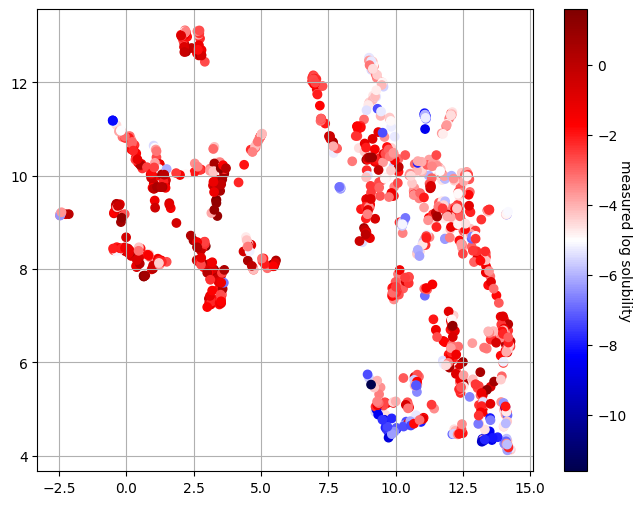

In [27]:
# 図5：タニモト距離行列に対するUMAP（測定溶解度で色分け）
fig = plt.subplots(figsize=(8, 6))

y = df['measured log solubility in mols per litre'].values
plt.scatter(T_umap[:,0],T_umap[:,1], c=y, cmap=plt.cm.seismic)

cbar = plt.colorbar()
cbar.set_label('measured log solubility', rotation = 270)

plt.grid()
plt.show()

## ①PCA・t-SNE・UMAPの比較

3つの次元削減手法（PCA、t-SNE、UMAP）で、それぞれ得られた2次元埋め込み上でのユークリッド距離が、元のタニモト距離をどれだけ保存できているかを、相関係数で比較してみましょう。相関係数が高いほど、低次元の可視化が元の化学構造の類似性関係を忠実に反映していると解釈できます。


In [28]:
# ①各手法の埋め込みが元のタニモト距離構造をどれだけ保っているかを比較する
from scipy.spatial.distance import pdist

orig_condensed = pdist(X, metric='jaccard')  # 元のタニモト距離（圧縮ベクトル形式）

corr_pca = np.corrcoef(pdist(T_pca[:, :2]), orig_condensed)[0, 1]
corr_tsne = np.corrcoef(pdist(T_tsne), orig_condensed)[0, 1]
corr_umap = np.corrcoef(pdist(T_umap), orig_condensed)[0, 1]

comparison = pd.DataFrame({
    '手法': ['PCA', 't-SNE', 'UMAP'],
    '元のタニモト距離との相関係数': [corr_pca, corr_tsne, corr_umap],
})
comparison

,手法,元のタニモト距離との相関係数
0,PCA,0.601299
1,t-SNE,0.506894
2,UMAP,0.513252


## ②まとめ

- Morganフィンガープリント（半径3、256ビット）からタニモト距離行列を計算し、それを入力としてPCA・t-SNE・UMAPで2次元に可視化しました。
- 3手法とも、測定溶解度で色分けしても明確なクラスター構造は見られませんでした。これは、タニモト係数（構造の類似性）と溶解度（物性値）が必ずしも一致しないことを示しています。構造が似ているからといって、物性まで似ているとは限りません。
- 上の比較表からわかるように、線形手法のPCAが元のタニモト距離構造を最もよく保存し（相関係数が最も高く）、非線形手法のt-SNE・UMAPはよりローカルな構造を強調する傾向があります。ただし、いずれも完全に元の距離関係を保存しているわけではない（相関係数は1にはほど遠い）点に注意してください。

## ③本ノートブックで扱っていないこと（今後の課題）

- タニモト距離行列を`metric='precomputed'`としてt-SNE・UMAPに正しく渡す方法（本編の《注意》を参照）は演習問題で扱います。
- t-SNE・UMAPのハイパーパラメータ（perplexity、n_neighbors、min_distなど）を変えた場合の埋め込みの変化は扱っていません。
- 溶解度を目的変数とした回帰モデルの構築は3_Solubility.ipynbで扱います。

## ④演習問題

1. `TSNE(n_components=2, random_state=66, metric='precomputed', init='random')`として`D`を渡した場合の埋め込みと、本編のデフォルト設定での埋め込みを比較してみましょう。元のタニモト距離との相関係数はどちらが高くなるでしょうか。
2. Morganフィンガープリントの半径（`radius`）やビット数（`fpSize`）を変えると、タニモト距離行列やPCAの寄与率がどう変わるか確認してみましょう。
3. `ref_smiles`を別の化合物に変更し、Delaneyデータセットの中から最も類似度の高い化合物を検索してみましょう。
4. `DataStructs.TanimotoSimilarity()`を使って、`ref_fps`とDelaneyデータセット中の任意の1化合物のフィンガープリントとのタニモト係数を計算し、`BulkTanimotoSimilarity()`で得た`similarity`リストの対応する値と一致することを確認しましょう。
5. `1 - similarity[i]`（タニモト係数から求めた距離）と、`scipy.spatial.distance.pdist(X, metric='jaccard')`から得られる同じ化合物ペアのタニモト距離が一致することを確認してみましょう。
